In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [3]:
import zipfile

with zipfile.ZipFile("archive (1).zip","r") as zip_ref:
    zip_ref.extractall("valorant")

In [4]:
import os

os.listdir("valorant")

['agent_id.csv',
 'stats.csv',
 'score.csv',
 'pick_ban.csv',
 'player_id.csv',
 'team_id.csv',
 '1v1.csv',
 'match_id.csv',
 'economy.csv',
 'counter_kill.csv']

In [5]:
stats = pd.read_csv("valorant/stats.csv")

score = pd.read_csv("valorant/score.csv")

teams = pd.read_csv("valorant/team_id.csv")

players = pd.read_csv("valorant/player_id.csv")

agents = pd.read_csv("valorant/agent_id.csv")

economy = pd.read_csv("valorant/economy.csv")

counter = pd.read_csv("valorant/counter_kill.csv")

pickban = pd.read_csv("valorant/pick_ban.csv")

duels = pd.read_csv("valorant/1v1.csv")

In [13]:
stats.shape

(1760, 21)

In [16]:
score.shape


(88, 21)

In [15]:
teams.shape

(16, 4)

In [17]:
players.shape

(81, 4)

In [18]:
agents.shape

(28, 4)

In [19]:
economy.shape

(176, 13)

In [20]:
counter.shape

(880, 17)

In [21]:
pickban.shape

(204, 5)

In [22]:
duels.shape

(13200, 9)

In [23]:
stats.isnull().sum()
score.isnull().sum()
teams.isnull().sum()
players.isnull().sum()
agents.isnull().sum()

,0
agent_id,0
agent,0
role,0
agent_png,0


In [24]:
stats.duplicated().sum()
score.duplicated().sum()
teams.duplicated().sum()
players.duplicated().sum()
agents.duplicated().sum()

np.int64(0)

In [25]:
stats.dtypes

,0
match_id,int64
game_id,int64
side,object
player,object
player_id,int64
agent,object
team_id,int64
country,object
rating,float64
acs,float64


In [26]:
stats["Kill_Difference"] = stats["kill"] - stats["death"]

In [27]:
stats["KDA"] = (stats["kill"] + stats["assist"]) / stats["death"]

In [28]:
stats = stats.rename(columns={"hs":"Headshot_Percentage"})

In [29]:
stats["FB_Difference"] = stats["fk"] - stats["fd"]

In [30]:
stats["Performance"] = np.where(stats["rating"]>=1.20,"Excellent","Average")

In [31]:
import matplotlib.pyplot as plt

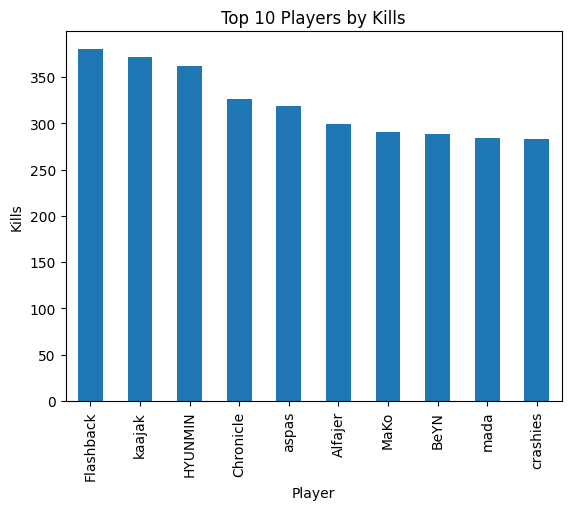

In [32]:
top_players = stats.groupby("player")["kill"].sum().sort_values(ascending=False).head(10)

top_players.plot(kind="bar")

plt.title("Top 10 Players by Kills")

plt.xlabel("Player")

plt.ylabel("Kills")

plt.show()

In [33]:
team_stats = pd.merge(stats,teams,on="team_id")

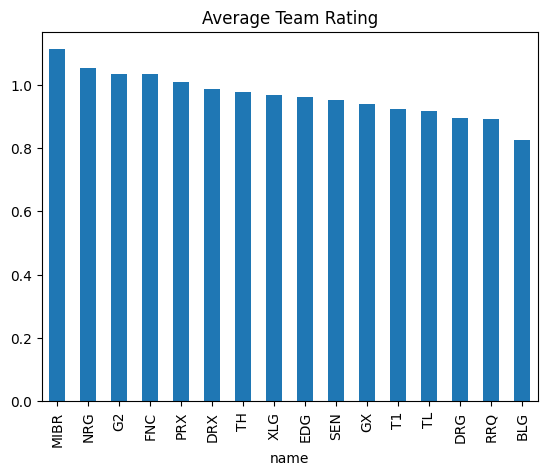

In [34]:
team_rating = team_stats.groupby("name")["rating"].mean().sort_values(ascending=False)

team_rating.plot(kind="bar")

plt.title("Average Team Rating")

plt.show()

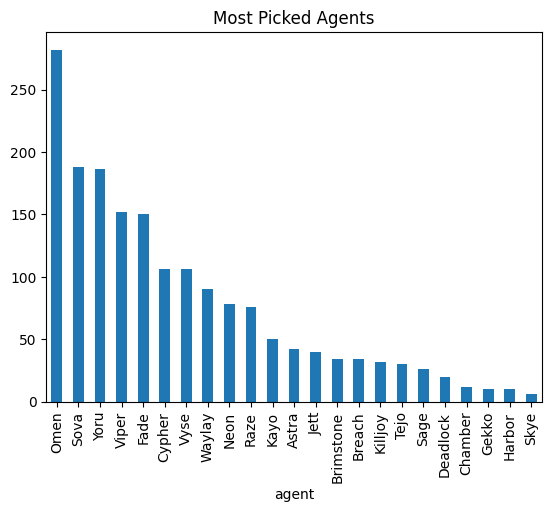

In [35]:
agent_pick = stats["agent"].value_counts()

agent_pick.plot(kind="bar")

plt.title("Most Picked Agents")

plt.show()

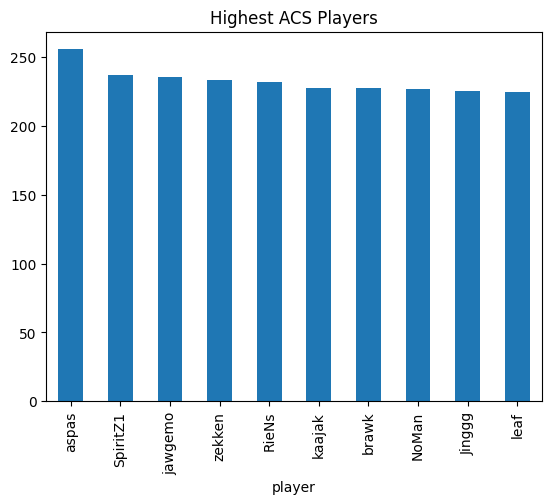

In [37]:
top_acs = stats.groupby("player")["acs"].mean().sort_values(ascending=False).head(10)

top_acs.plot(kind="bar")

plt.title("Highest ACS Players")

plt.show()

In [40]:
stats.to_csv("cleaned_stats.csv", index=False)

score.to_csv("cleaned_score.csv", index=False)

teams.to_csv("cleaned_team.csv", index=False)

players.to_csv("cleaned_player.csv", index=False)

agents.to_csv("cleaned_agent.csv", index=False)

economy.to_csv("cleaned_economy.csv", index=False)

counter.to_csv("cleaned_counter_kill.csv", index=False)

pickban.to_csv("cleaned_pick_ban.csv", index=False)

In [41]:
from google.colab import files

In [42]:
files.download("cleaned_stats.csv")
files.download("cleaned_score.csv")
files.download("cleaned_team.csv")
files.download("cleaned_player.csv")
files.download("cleaned_agent.csv")
files.download("cleaned_economy.csv")
files.download("cleaned_counter_kill.csv")
files.download("cleaned_pick_ban.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import sqlite3

In [44]:
conn = sqlite3.connect("valorant.db")

In [45]:
cursor = conn.cursor()


In [46]:
stats.to_sql("stats", conn, if_exists="replace", index=False)

score.to_sql("score", conn, if_exists="replace", index=False)

teams.to_sql("teams", conn, if_exists="replace", index=False)

players.to_sql("players", conn, if_exists="replace", index=False)

agents.to_sql("agents", conn, if_exists="replace", index=False)

28

In [47]:
query = """
SELECT *
FROM stats
LIMIT 10;
"""

pd.read_sql(query, conn)

,match_id,game_id,side,player,player_id,agent,team_id,country,rating,acs,...,adr,Headshot_Percentage,fk,fd,deltafkfd,event_name,Kill_Difference,KDA,FB_Difference,Performance
0,542195,233397,t,something,17086,Yoru,624,Russia,1.33,199.0,...,137.0,16%,1,0,1,Group Stage: Opening (A),2,2.600000,1,Excellent
1,542195,233397,t,Jinggg,7378,Raze,624,Singapore,1.11,239.0,...,148.0,13%,3,2,1,Group Stage: Opening (A),1,1.428571,1,Average
2,542195,233397,t,f0rsakeN,9801,Brimstone,624,Indonesia,1.99,341.0,...,218.0,38%,1,1,0,Group Stage: Opening (A),10,5.250000,0,Excellent
3,542195,233397,t,d4v41,9803,Viper,624,Malaysia,1.37,236.0,...,167.0,14%,1,0,1,Group Stage: Opening (A),4,2.000000,1,Excellent
4,542195,233397,t,PatMen,13744,Fade,624,Philippines,0.99,173.0,...,118.0,28%,0,1,-1,Group Stage: Opening (A),2,1.750000,-1,Average
5,542195,233397,t,Rarga,22047,Raze,13581,Russia,0.90,197.0,...,138.0,36%,2,1,1,Group Stage: Opening (A),-1,1.111111,1,Average
6,542195,233397,t,Viva,36415,Brimstone,13581,China,1.13,194.0,...,133.0,50%,0,1,-1,Group Stage: Opening (A),1,1.375000,-1,Average
7,542195,233397,t,NoMan,11527,Skye,13581,Hong Kong,1.06,249.0,...,157.0,46%,0,0,0,Group Stage: Opening (A),1,1.100000,0,Average
8,542195,233397,t,coconut,12365,Gekko,13581,Hong Kong,0.51,148.0,...,94.0,43%,3,2,1,Group Stage: Opening (A),-3,0.888889,1,Average
9,542195,233397,t,happywei,37927,Viper,13581,Taiwan,0.70,162.0,...,119.0,30%,1,2,-1,Group Stage: Opening (A),-2,0.888889,-1,Average


In [48]:
query = """
SELECT player,
AVG(rating) AS Avg_Rating
FROM stats
GROUP BY player
ORDER BY Avg_Rating DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,player,Avg_Rating
0,aspas,1.325667
1,brawk,1.206471
2,RieNs,1.193750
3,johnqt,1.165833
4,kaajak,1.143409
5,cortezia,1.120000
6,something,1.116562
7,leaf,1.112083
8,NoMan,1.105000
9,Smoggy,1.102000


In [50]:
query = """
SELECT player,
SUM(kill) AS Total_Kills
FROM stats
GROUP BY player
ORDER BY Total_Kills DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,player,Total_Kills
0,Flashback,380
1,kaajak,372
2,HYUNMIN,362
3,Chronicle,326
4,aspas,319
5,Alfajer,299
6,MaKo,291
7,BeYN,288
8,mada,284
9,crashies,283


In [51]:
query = """
SELECT player,
AVG(Headshot_Percentage) AS HS_Percentage
FROM stats
GROUP BY player
ORDER BY HS_Percentage DESC
LIMIT 10;
"""

pd.read_sql(query, conn)


,player,HS_Percentage
0,Kushy,41.428571
1,Demon1,40.500000
2,westside,40.230769
3,HYUNMIN,39.863636
4,RieNs,39.208333
5,happywei,38.714286
6,keiko,38.214286
7,stax,37.583333
8,free1ng,37.250000
9,cortezia,37.200000


In [55]:
query = """
SELECT player,
AVG(KDA) AS Avg_KDA
FROM stats
GROUP BY player
ORDER BY Avg_KDA DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,player,Avg_KDA
0,xffero,inf
1,westside,inf
2,skuba,inf
3,brawk,inf
4,xenom,2.558472
5,Boo,2.342560
6,aspas,2.185887
7,N4RRATE,2.174170
8,Monyet,2.165391
9,Verno,2.125833


In [56]:
query = """
SELECT player,
AVG(death) AS Avg_Deaths
FROM stats
GROUP BY player
ORDER BY Avg_Deaths ASC
LIMIT 10;
"""

pd.read_sql(query, conn)

,player,Avg_Deaths
0,nephh,6.000000
1,cortezia,6.200000
2,johnqt,6.250000
3,xenom,6.333333
4,Verno,6.366667
5,aspas,6.400000
6,MaKo,6.454545
7,Boaster,6.477273
8,crashies,6.636364
9,doma,6.666667


In [60]:
query = """
SELECT
t.name AS Team_Name,
AVG(s.rating) AS Avg_Rating,
RANK() OVER(
    ORDER BY AVG(s.rating) DESC
) AS Team_Rank
FROM stats s
JOIN teams t
ON s.team_id = t.team_id
GROUP BY t.name;
"""

pd.read_sql(query, conn)

,Team_Name,Avg_Rating,Team_Rank
0,MIBR,1.110667,1
1,NRG,1.053765,2
2,G2,1.033333,3
3,FNC,1.032955,4
4,PRX,1.006500,5
5,DRX,0.984500,6
6,TH,0.975500,7
7,XLG,0.967000,8
8,EDG,0.961000,9
9,SEN,0.950167,10
